In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Dataset: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

In [3]:
df = pd.read_csv("creditcard.csv")
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
# imbalance
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

### Exploratory Data Analysis

In [7]:
fraud = df[df["Class"] == 1]
normal = df[df["Class"] == 0]

In [8]:
print("Fraud:",fraud.shape)
print("Normal:",normal.shape)
fraud.head()

Fraud: (492, 31)
Normal: (284315, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
541,406.0,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.00,1
623,472.0,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00,1
4920,4462.0,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,...,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,239.93,1
6108,6986.0,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,...,0.573574,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,59.00,1
6329,7519.0,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,...,-0.379068,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1.00,1


In [9]:
fraud.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,...,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.0
mean,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321,1.0
std,47835.365138,6.783687,4.291216,7.110937,2.873318,5.372468,1.858124,7.206773,6.797831,2.500896,...,3.869304,1.494602,1.579642,0.515577,0.797205,0.471679,1.376766,0.547291,256.683288,0.0
min,406.000000,-30.552380,-8.402154,-31.103685,-1.313275,-22.105532,-6.406267,-43.557242,-41.044261,-13.434066,...,-22.797604,-8.887017,-19.254328,-2.028024,-4.781606,-1.152671,-7.263482,-1.869290,0.000000,1.0
25%,41241.500000,-6.036063,1.188226,-8.643489,2.373050,-4.792835,-2.501511,-7.965295,-0.195336,-3.872383,...,0.041787,-0.533764,-0.342175,-0.436809,-0.314348,-0.259416,-0.020025,-0.108868,1.000000,1.0
50%,75568.500000,-2.342497,2.717869,-5.075257,4.177147,-1.522962,-1.424616,-3.034402,0.621508,-2.208768,...,0.592146,0.048434,-0.073135,-0.060795,0.088371,0.004321,0.394926,0.146344,9.250000,1.0
75%,128483.000000,-0.419200,4.971257,-2.276185,6.348729,0.214562,-0.413216,-0.945954,1.764879,-0.787850,...,1.244611,0.617474,0.308378,0.285328,0.456515,0.396733,0.826029,0.381152,105.890000,1.0
max,170348.000000,2.132386,22.057729,2.250210,12.114672,11.095089,6.474115,5.802537,20.007208,3.353525,...,27.202839,8.361985,5.466230,1.091435,2.208209,2.745261,3.052358,1.779364,2125.870000,1.0


In [10]:
normal.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,...,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.0
mean,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,...,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022,0.0
std,47484.015786,1.929814,1.636146,1.459429,1.399333,1.356952,1.329913,1.178812,1.161283,1.089372,...,0.716743,0.723668,0.621541,0.605776,0.520673,0.482241,0.399847,0.329570,250.105092,0.0
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-31.764946,-73.216718,-6.290730,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.0
25%,54230.000000,-0.917544,-0.599473,-0.884541,-0.850077,-0.689398,-0.766847,-0.551442,-0.208633,-0.640412,...,-0.228509,-0.542403,-0.161702,-0.354425,-0.317145,-0.327074,-0.070852,-0.052950,5.650000,0.0
50%,84711.000000,0.020023,0.064070,0.182158,-0.022405,-0.053457,-0.273123,0.041138,0.022041,-0.049964,...,-0.029821,0.006736,-0.011147,0.041082,0.016417,-0.052227,0.001230,0.011199,22.000000,0.0
75%,139333.000000,1.316218,0.800446,1.028372,0.737624,0.612181,0.399619,0.571019,0.326200,0.598230,...,0.185626,0.528407,0.147522,0.439869,0.350594,0.240671,0.090573,0.077962,77.050000,0.0
max,172792.000000,2.454930,18.902453,9.382558,16.875344,34.801666,73.301626,120.589494,18.709255,15.594995,...,22.614889,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,0.0


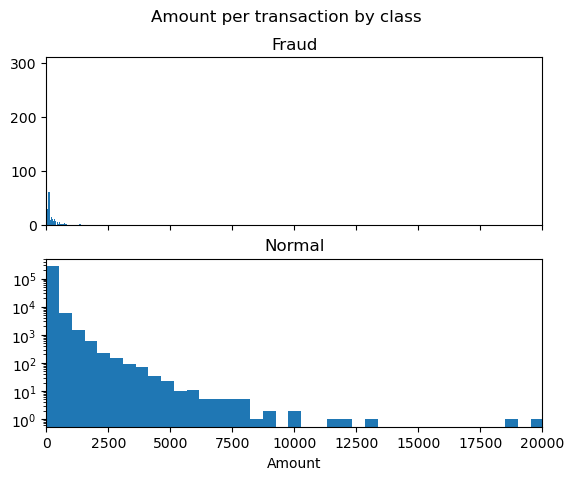

In [11]:
# Sınıflara göre işlem başına tutarı kontrol edelim.
figure, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
figure.suptitle("Amount per transaction by class")
ax1.hist(fraud.Amount, bins=50)
ax1.set_title("Fraud")
ax2.hist(normal.Amount, bins=50)
ax2.set_title("Normal")
plt.xlim((0,20000))
plt.xlabel("Amount")
plt.yscale("log")
plt.show()

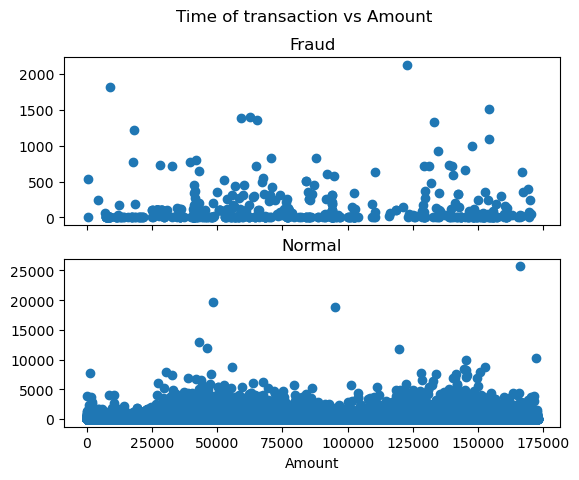

In [12]:
figure, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
figure.suptitle("Time of transaction vs Amount")
ax1.scatter(fraud.Time, fraud.Amount)
ax1.set_title("Fraud")
ax2.scatter(normal.Time, normal.Amount)
ax2.set_title("Normal")
plt.xlabel("Amount")
plt.show()

In [13]:
# EDA tamamlandı, sahtekarlık/normal oranının çok düşük olduğunu gördük ve tam olarak o sayıya ihtiyacımız var.

In [14]:
df["Class"].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

In [15]:
fraud_ration = 0.001727

### Isolation Forest

In [16]:
# Anormallik tespitinin burada işe yarayıp yaramadığını görmek için modelleri karşılaştıralım.
from sklearn.ensemble import IsolationForest

In [17]:
iso = IsolationForest(
    n_estimators=200,
    contamination=fraud_ration,
    max_features=1.0,
    max_samples="auto",
    n_jobs=-1,
    random_state=42
)

In [18]:
X = df.drop("Class", axis=1)

In [19]:
iso.fit(X)

IsolationForest(contamination=0.001727, n_estimators=200, n_jobs=-1,
                random_state=42)

In [20]:
df["iso_raw"] = iso.predict(X)

In [21]:
df['iso_raw'].unique()

array([ 1, -1])

In [22]:
# 1 -> normal
# -1 -> anomaly 

In [23]:
df["iso_pred"] = df["iso_raw"].map({1:0, -1:1})

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
X = df.drop(["Class", "iso_raw", "iso_pred"], axis=1)
y = df["Class"]

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42, stratify=y)

In [27]:
iso_test_pred = df.loc[X_test.index, "iso_pred"]

In [28]:
from sklearn.metrics import classification_report

In [29]:
print(classification_report(y_test, iso_test_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.24      0.24      0.24       148

    accuracy                           1.00     85443
   macro avg       0.62      0.62      0.62     85443
weighted avg       1.00      1.00      1.00     85443



In [30]:
# recall, %24 biraz düşük görünüyor ancak verilerin tamamının sadece %0,17'sini oluşturduğu düşünüldüğünde bu bir anormallik olabilir
# Aslında iyi olabilir. Şimdi de aslında neye bakmamız gerektiğine bakalım.

In [31]:
df["anomaly_score"] = iso.decision_function(X)

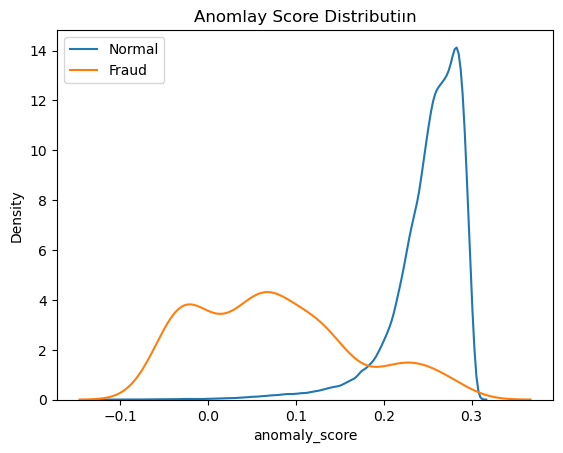

In [32]:
sns.kdeplot(df[df["Class"]==0]["anomaly_score"], label="Normal")
sns.kdeplot(df[df["Class"]==1]["anomaly_score"], label="Fraud")
plt.title("Anomlay Score Distributiın")
plt.legend()
plt.show()

In [33]:
# Anormallik skoru, anormalliklerde sola, normal durumlarda ise sağa doğru dağılır ve bu dağılım tam olarak şöyle olmalıdır:
# En şüpheli %1'lik işlemlere bakalım.

In [34]:
df["anomaly_score"].quantile(0.01)

np.float64(0.08186793737658911)

In [35]:
threshold = df["anomaly_score"].quantile(0.01)

In [36]:
# Eşik değerini 0.0017 yerine bu değere çıkarırsak ne olacağına bakalım.

In [37]:
df["iso_custom"] = (df["anomaly_score"] < threshold).astype(int)

In [38]:
print(classification_report(df["Class"], df["iso_custom"]))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00    284315
           1       0.10      0.58      0.17       492

    accuracy                           0.99    284807
   macro avg       0.55      0.79      0.58    284807
weighted avg       1.00      0.99      0.99    284807



In [39]:
# Gördüğünüz gibi, recall aslında artıyor ve precision %1 düşüyor. Gerçek hayatta istediğimiz şey de bu.

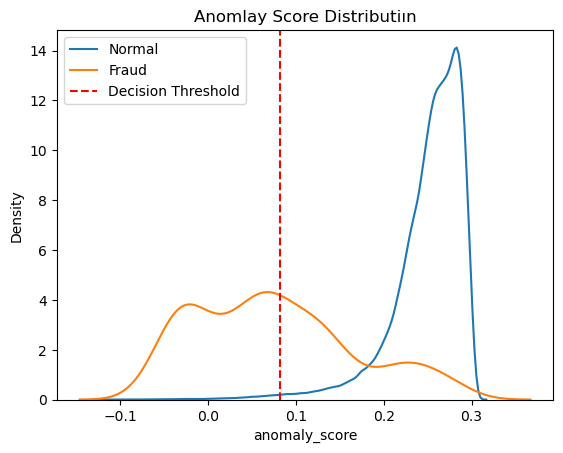

In [40]:
sns.kdeplot(df[df["Class"]==0]["anomaly_score"], label="Normal")
sns.kdeplot(df[df["Class"]==1]["anomaly_score"], label="Fraud")
plt.axvline(threshold, color="red", linestyle="--", label="Decision Threshold")
plt.title("Anomlay Score Distributiın")
plt.legend()
plt.show()

In [41]:
# Isolation Forest modelinde, karar sınırını öğrenir. Şüphe puanı üretir. 
# Ancak işletmeler, bir şeyin sahte olup olmadığını belirlemek için burada şu şekilde karar verirler: 

# Gerçek hayatta bankalar her gün milyonlarca işlem alıyor 
# Bu yüzden zaten sadece en şüpheli işlemlerin %1'ini değerlendirmeye göndermek istiyorlar 

In [42]:
# Değerleri buna göre sıralarsak
df_sorted = df.sort_values("anomaly_score")

In [43]:
# o zaman top %1'i alırız
k = int(len(df_sorted) * 0.01)
top_k = df_sorted.head(k)
top_k

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V25,V26,V27,V28,Amount,Class,iso_raw,iso_pred,anomaly_score,iso_custom
274771,166198.0,-35.548539,-31.850484,-48.325589,15.304184,-113.743307,73.301626,120.589494,-27.347360,-3.872425,...,4.554683,3.415636,31.612198,-15.430084,25691.16,0,-1,1,-0.120212,1
173353,121450.0,-28.262775,-26.551515,-15.930586,6.945207,-19.203497,13.461737,23.718783,-9.419314,5.264773,...,-3.684737,-0.106886,4.071877,-2.383081,4861.64,0,-1,1,-0.118682,1
173054,121340.0,-22.132223,-19.815536,-11.183644,4.829787,-13.128465,10.689779,18.257057,-8.685409,5.250410,...,-2.965101,0.149369,4.077221,-1.975801,4543.64,0,-1,1,-0.106926,1
176335,122723.0,-35.274010,-34.889342,-15.070015,9.211564,-6.226835,3.828063,10.778805,-6.462003,6.588395,...,-4.564506,-0.594620,1.110848,-0.714247,1676.60,0,-1,1,-0.105962,1
206255,136137.0,-40.042537,-38.430842,-21.277176,10.527243,-16.296090,8.799515,19.553200,-6.221785,6.121324,...,-4.196468,-0.851794,0.375152,-1.178134,1676.60,0,-1,1,-0.104298,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
270482,164095.0,-5.156486,-4.047256,0.681539,1.835290,5.604813,-2.500778,-4.655969,-2.316873,1.409756,...,-0.765440,-1.073832,1.863624,-0.686986,21.63,0,1,0,0.081742,1
231831,146946.0,-5.944667,5.788085,-2.382159,-2.258326,-0.158975,-1.300510,1.559494,-0.762640,5.656877,...,0.587998,-0.233592,2.880563,1.176082,1.79,0,1,0,0.081772,1
199679,133081.0,-2.358533,3.313893,-3.295007,-0.346871,-0.059448,2.510808,-5.314225,-12.509177,-1.549689,...,-0.504123,-0.217408,-0.236612,0.107879,36.29,0,1,0,0.081786,1
178253,123550.0,-11.219660,1.508430,-5.736577,-2.116511,-8.195979,-0.529104,-4.133891,5.827402,-1.384015,...,0.899128,-0.086430,0.073954,-0.304958,152.65,0,1,0,0.081792,1


In [44]:
frauds_captured = top_k["Class"].sum()
total_frauds = df["Class"].sum()

recall_at_k = frauds_captured / total_frauds
print(recall_at_k)

0.5792682926829268


In [45]:
# Bu, işlemlerin yalnızca %1'ini değerlendirerek dolandırıcılığın neredeyse %60'ını ortaya çıkardığımız anlamına geliyor.
# Bunu şu şekilde genişletebiliriz:

In [46]:
percentages = np.linspace(0.001, 0.05, 30)
percentages * 100

array([0.1       , 0.26896552, 0.43793103, 0.60689655, 0.77586207,
       0.94482759, 1.1137931 , 1.28275862, 1.45172414, 1.62068966,
       1.78965517, 1.95862069, 2.12758621, 2.29655172, 2.46551724,
       2.63448276, 2.80344828, 2.97241379, 3.14137931, 3.31034483,
       3.47931034, 3.64827586, 3.81724138, 3.9862069 , 4.15517241,
       4.32413793, 4.49310345, 4.66206897, 4.83103448, 5.        ])

In [47]:
recalls = []

total_frauds = df["Class"].sum()

for p in percentages:
    k = int(len(df_sorted) * p)
    captured = df_sorted.head(k)["Class"].sum()
    recalls.append(captured / total_frauds)

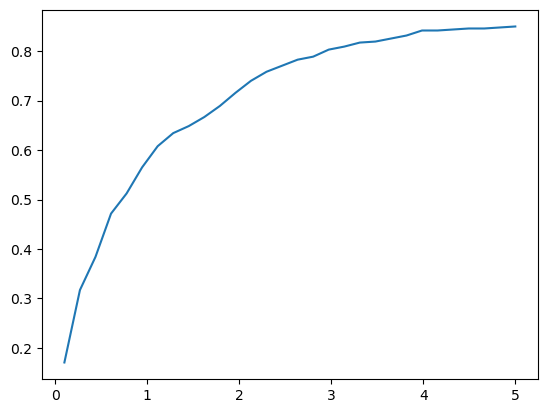

In [48]:
plt.plot(percentages * 100, recalls)

In [49]:
# Yani toplam işlemlerin %5'ini inceleyerek sahte işlemlerin %80'inden fazlasını tespit edebilirsiniz.

# Bu gerçek hayattaki bir durum için yeterli mi? Muhtemelen değil. 
# Gerçek hayatta bankalar, denetimsiz öğrenmeden öğrendikleri bu bilgiyi denetimli öğrenmeye aktarmaya çalışırlar.

# Denetimli öğrenme algoritması için sağlam bir özellik sağlamak amacıyla df'de anomaly_score kullanabiliriz. 
# Nasıl çalıştığına bakalım:

In [50]:
# unsupervised learning -> supervised learning -> human

In [51]:
from xgboost import XGBClassifier

In [52]:
X = df.drop(["Class","iso_raw","iso_pred","iso_custom"], axis=1)
y = df["Class"]

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42, stratify=y)

In [54]:
len(y_train[y_train == 0])

199020

In [55]:
len(y_train[y_train == 1])

344

In [56]:
344 / 199020

0.0017284695005527083

In [57]:
xgb = XGBClassifier(
    scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1]),
    n_jobs = -1,
    random_state = 42
)

In [58]:
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=-1, num_parallel_tree=None, ...)

In [59]:
print(classification_report(y_test, xgb.predict(X_test)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.89      0.78      0.83       148

    accuracy                           1.00     85443
   macro avg       0.94      0.89      0.92     85443
weighted avg       1.00      1.00      1.00     85443

